# 🔍 Análise Preditiva de Churn de Clientes
**Banco de dados:** Contoso Retail DW (SQL Server)  
**Algoritmo:** Random Forest Classifier  
**Autor:** Jefferson da Silva Araújo  

---

## 📋 Objetivo
Construir um modelo de Machine Learning capaz de **identificar clientes com risco de churn** — aqueles que pararam de realizar compras — com base em dados históricos transacionais.

A identificação antecipada permite que equipes de marketing tomem ações preventivas como:
- 📧 Campanhas de reativação personalizadas
- 🎯 Ofertas direcionadas para clientes em risco
- 📞 Contato proativo do time de relacionamento

---

## 🗂️ Estrutura do Notebook
1. Importação de bibliotecas
2. Conexão com SQL Server e carregamento dos dados
3. Análise Exploratória de Dados (EDA)
4. Preparação dos dados para ML
5. Treinamento do modelo
6. Avaliação e métricas
7. Feature Importance
8. Conclusões e próximos passos

---
## 1️⃣ Importação de Bibliotecas

In [2]:
# ── Conexão com banco de dados ────────────────────────────────────────────
import pyodbc

# ── Manipulação e análise de dados ───────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualização ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Machine Learning ──────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

# ── Configurações gerais ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Estilo visual dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('✅ Bibliotecas importadas com sucesso!')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')

✅ Bibliotecas importadas com sucesso!
   pandas  : 2.3.1
   numpy   : 2.3.2


---
## 2️⃣ Conexão com SQL Server e Carregamento dos Dados

### 📐 Sobre a View SQL utilizada
Os dados são carregados a partir da view `vw_Dados_Treinamento_Churn`, que foi construída no SQL Server para realizar:

- **Agregação** das transações por cliente
- **Engenharia de features** (Idade, Recência, Volume de compras)
- **Definição do target** (DeixouDeComprar = 1 se >60 dias sem compra)

> ⚠️ **Nota técnica:** A data de referência usa `MAX(DateKey)` do próprio dataset ao invés de `GETDATE()`, pois o Contoso possui dados até 2009. Usar a data atual causaria Data Leakage (todos os clientes seriam marcados como churn).

In [3]:
# ── Parâmetros de conexão com o SQL Server ────────────────────────────────
# Autenticação Windows (Trusted Connection) — sem necessidade de usuário/senha
dados_conexao = (
    "Driver={SQL Server};"
    "Server=ARAUJO;"               # Nome do servidor local
    "Database=ContosoRetailDW;"    # Banco de dados Contoso
    "Trusted_Connection=yes;"      # Usa credencial do Windows
)

# ── Query SQL ─────────────────────────────────────────────────────────────
# Chamamos a View que já faz toda a agregação e engenharia de features
comando_sql = "SELECT * FROM dbo.vw_Dados_Treinamento_Churn"

# ── Execução da conexão e carregamento ───────────────────────────────────
print("🔌 Conectando ao SQL Server...")
try:
    conexao = pyodbc.connect(dados_conexao)
    print("✅ Conexão estabelecida!")
    
    print("📥 Carregando dados da View...")
    df = pd.read_sql(comando_sql, conexao)
    
    conexao.close()  # Boa prática: fechar a conexão logo após o carregamento
    print(f"✅ Conexão encerrada. {len(df):,} registros carregados!")
    
except Exception as e:
    print(f"❌ Erro na conexão: {e}")

# ── Visão inicial dos dados ───────────────────────────────────────────────
print("\n📊 Primeiros registros:")
df.head()

🔌 Conectando ao SQL Server...
✅ Conexão estabelecida!
📥 Carregando dados da View...
✅ Conexão encerrada. 18,484 registros carregados!

📊 Primeiros registros:


,CustomerKey,Idade,TotalItensComprados,TotalItensDevolvidos,DiasDesdeUltimaCompra,DeixouDeComprar
0,2,61,97,0,6004,0
1,4,58,125,0,6004,0
2,9,62,114,1,6004,0
3,11,62,112,1,6004,0
4,18,82,247,0,5999,0


---
## 3️⃣ Análise Exploratória de Dados (EDA)

Antes de treinar qualquer modelo, precisamos entender os dados:
- **Dimensões** do dataset
- **Tipos** de cada variável
- **Valores nulos** e anomalias
- **Distribuição** das variáveis
- **Balanceamento** do target

In [4]:
# ── Informações gerais do dataset ─────────────────────────────────────────
print("=" * 55)
print(" VISÃO GERAL DO DATASET")
print("=" * 55)
print(f" Linhas    : {df.shape[0]:>10,}")
print(f" Colunas   : {df.shape[1]:>10}")
print(f" Memória   : {df.memory_usage(deep=True).sum() / 1024**2:>9.2f} MB")
print("=" * 55)

print("\n📋 Tipos de dados:")
print(df.dtypes)

print("\n🔍 Valores nulos por coluna:")
nulos = df.isnull().sum()
print(nulos[nulos >= 0].to_string())

print("\n📈 Estatísticas descritivas:")
df.describe().round(2)

 VISÃO GERAL DO DATASET
 Linhas    :     18,484
 Colunas   :          6
 Memória   :      0.85 MB

📋 Tipos de dados:
CustomerKey              int64
Idade                    int64
TotalItensComprados      int64
TotalItensDevolvidos     int64
DiasDesdeUltimaCompra    int64
DeixouDeComprar          int64
dtype: object

🔍 Valores nulos por coluna:
CustomerKey              0
Idade                    0
TotalItensComprados      0
TotalItensDevolvidos     0
DiasDesdeUltimaCompra    0
DeixouDeComprar          0

📈 Estatísticas descritivas:


,CustomerKey,Idade,TotalItensComprados,TotalItensDevolvidos,DiasDesdeUltimaCompra,DeixouDeComprar
count,18484.00,18484.00,18484.00,18484.00,18484.00,18484.00
mean,9242.50,64.42,152.35,0.87,6047.65,0.11
std,5336.02,11.25,59.62,1.02,104.08,0.31
min,1.00,46.00,68.00,0.00,5999.00,0.00
25%,4621.75,56.00,104.00,0.00,6003.00,0.00
50%,9242.50,63.00,123.00,1.00,6010.00,0.00
75%,13863.25,72.00,195.00,1.00,6031.00,0.00
max,18484.00,116.00,376.00,8.00,6377.00,1.00



🎯 Distribuição do Target (DeixouDeComprar):
----------------------------------------
  Classe 0 — Cliente Ativo : 16,474 (89.1%)
  Classe 1 — Churn         :  2,010 (10.9%)
----------------------------------------
⚠️  ATENÇÃO: Dataset desbalanceado! Classe minoritária abaixo de 20%.
   Considere: SMOTE, class_weight='balanced' ou ajuste de threshold.


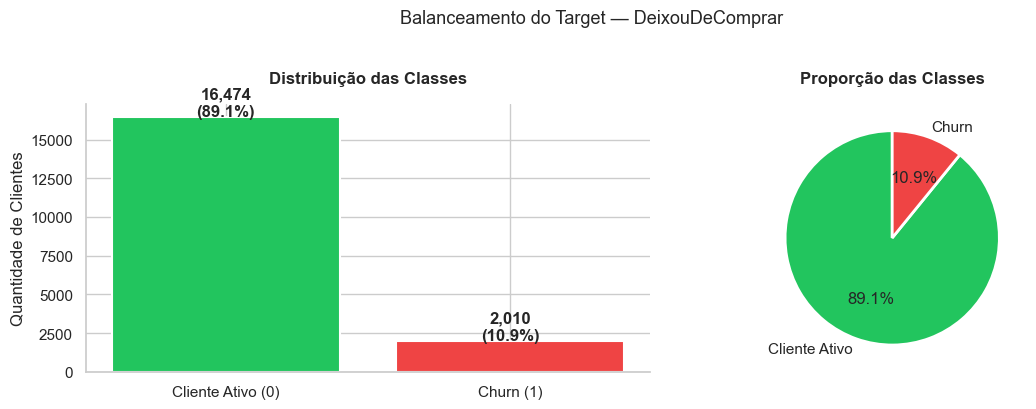

In [5]:
# ── Balanceamento do Target ───────────────────────────────────────────────
# Verificar se o dataset está balanceado entre classes 0 e 1
# Desbalanceamento pode prejudicar o treinamento do modelo

contagem_classes = df['DeixouDeComprar'].value_counts()
pct_classes = df['DeixouDeComprar'].value_counts(normalize=True) * 100

print("\n🎯 Distribuição do Target (DeixouDeComprar):")
print("-" * 40)
print(f"  Classe 0 — Cliente Ativo : {contagem_classes[0]:>6,} ({pct_classes[0]:.1f}%)")
print(f"  Classe 1 — Churn         : {contagem_classes[1]:>6,} ({pct_classes[1]:.1f}%)")
print("-" * 40)

if pct_classes[1] < 20:
    print("⚠️  ATENÇÃO: Dataset desbalanceado! Classe minoritária abaixo de 20%.")
    print("   Considere: SMOTE, class_weight='balanced' ou ajuste de threshold.")

# Gráfico de distribuição
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
cores = ['#22c55e', '#ef4444']
axes[0].bar(['Cliente Ativo (0)', 'Churn (1)'], contagem_classes.values, color=cores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuição das Classes', fontweight='bold', pad=15)
axes[0].set_ylabel('Quantidade de Clientes')
for i, v in enumerate(contagem_classes.values):
    axes[0].text(i, v + 50, f'{v:,}\n({pct_classes.values[i]:.1f}%)', ha='center', fontweight='bold')

# Gráfico de pizza
axes[1].pie(contagem_classes.values, labels=['Cliente Ativo', 'Churn'],
            colors=cores, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção das Classes', fontweight='bold', pad=15)

plt.suptitle('Balanceamento do Target — DeixouDeComprar', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

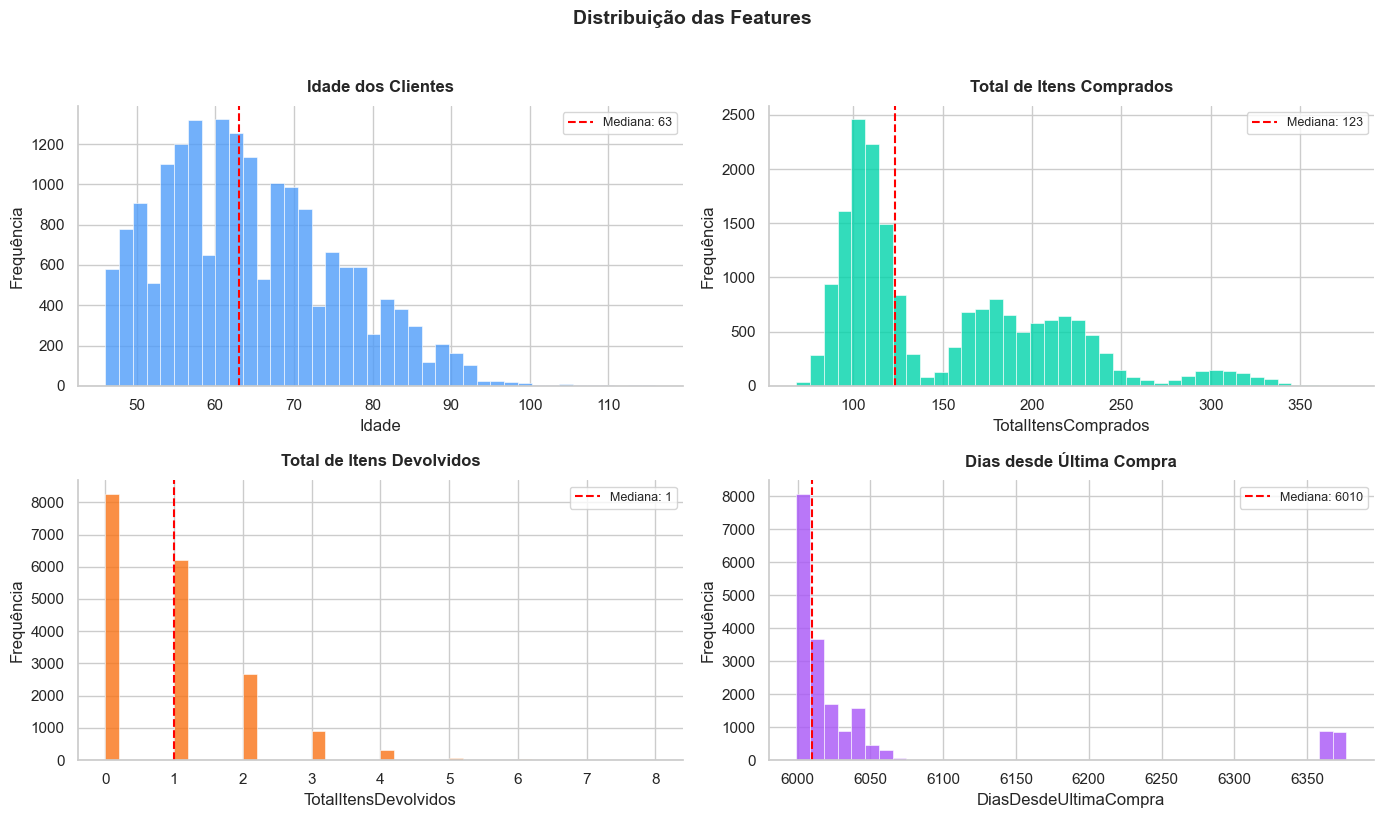

In [6]:
# ── Distribuição das Features ─────────────────────────────────────────────
# Histogramas para entender a distribuição de cada variável numérica

features = ['Idade', 'TotalItensComprados', 'TotalItensDevolvidos', 'DiasDesdeUltimaCompra']
titulos = ['Idade dos Clientes', 'Total de Itens Comprados', 'Total de Itens Devolvidos', 'Dias desde Última Compra']
cores_hist = ['#4f9cf9', '#00d4aa', '#f97316', '#a855f7']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (feat, titulo, cor) in enumerate(zip(features, titulos, cores_hist)):
    axes[i].hist(df[feat], bins=40, color=cor, alpha=0.8, edgecolor='white', linewidth=0.5)
    axes[i].set_title(titulo, fontweight='bold', pad=10)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frequência')
    # Linha de mediana
    mediana = df[feat].median()
    axes[i].axvline(mediana, color='red', linestyle='--', linewidth=1.5, label=f'Mediana: {mediana:.0f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribuição das Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

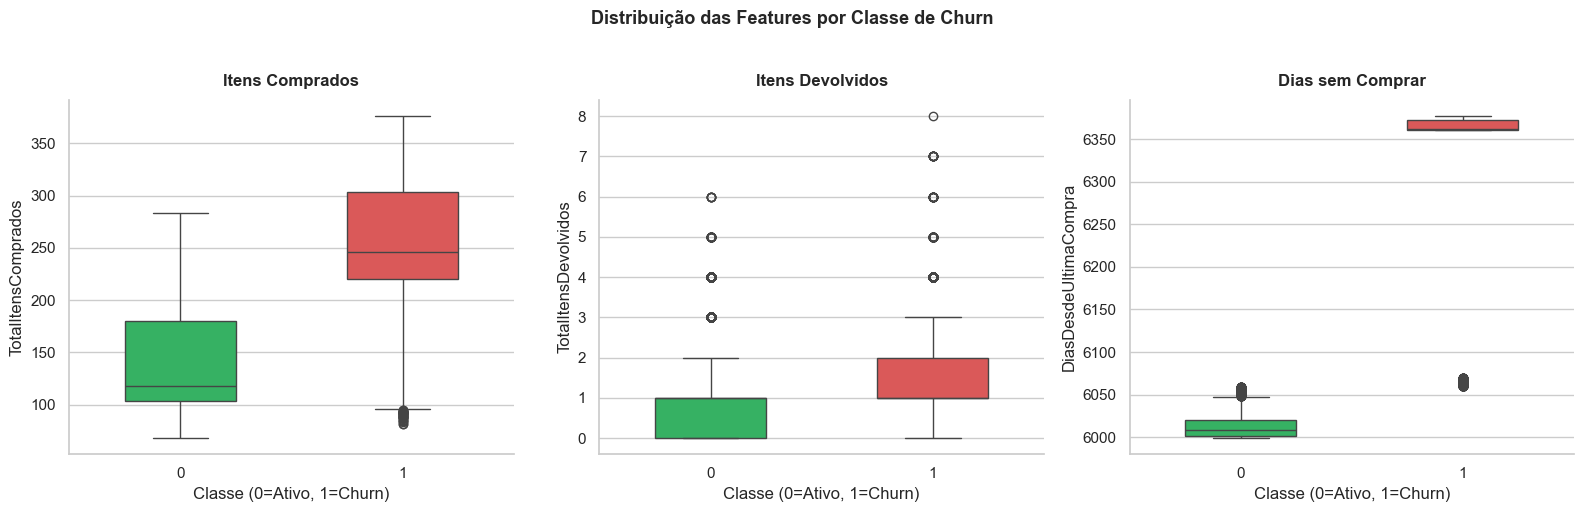


📊 Interpretação:
Se as caixas estiverem bem separadas → a feature tem alto poder preditivo
Se as caixas estiverem sobrepostas   → a feature tem menor contribuição


In [8]:
# ── Boxplot: Comparação entre Clientes Ativos vs Churn ───────────────────
# Mostra se as features se comportam diferente entre as duas classes
# Se as "caixas" estiverem separadas, a feature é um bom preditor!

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features_box = ['TotalItensComprados', 'TotalItensDevolvidos', 'DiasDesdeUltimaCompra']
titulos_box = ['Itens Comprados', 'Itens Devolvidos', 'Dias sem Comprar']

for i, (feat, titulo) in enumerate(zip(features_box, titulos_box)):
    sns.boxplot(
        data=df, x='DeixouDeComprar', y=feat,
        palette={'0': '#22c55e', '1': '#ef4444'},
        ax=axes[i], width=0.5
    )
    axes[i].set_title(titulo, fontweight='bold', pad=10)
    axes[i].set_xlabel('Classe (0=Ativo, 1=Churn)')
    axes[i].set_ylabel(feat)

plt.suptitle('Distribuição das Features por Classe de Churn', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Interpretação:")
print("Se as caixas estiverem bem separadas → a feature tem alto poder preditivo")
print("Se as caixas estiverem sobrepostas   → a feature tem menor contribuição")

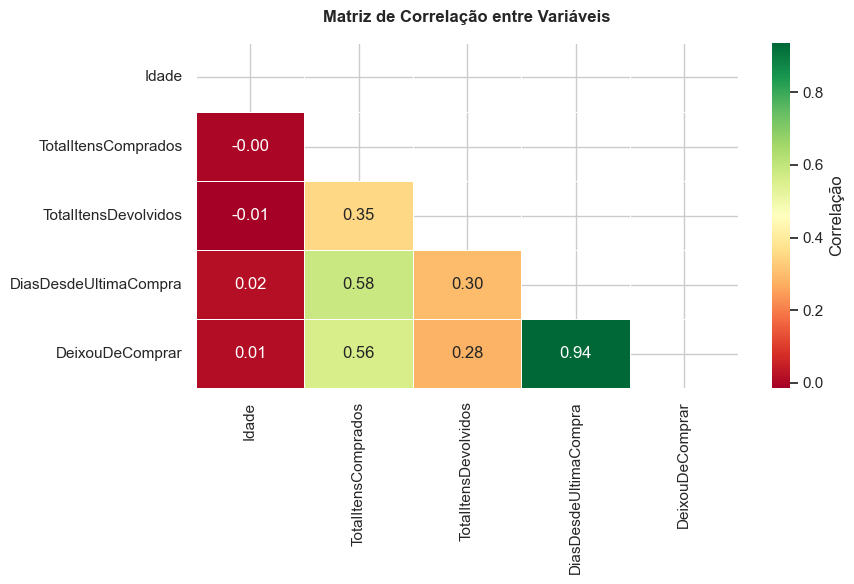


🎯 Correlação de cada feature com DeixouDeComprar:
  🔴 DiasDesdeUltimaCompra          +0.9360
  🔴 TotalItensComprados            +0.5573
  🔴 TotalItensDevolvidos           +0.2816
  ⚪ Idade                          +0.0147


In [9]:
# ── Matriz de Correlação ──────────────────────────────────────────────────
# Correlação entre as features e o target
# Valores próximos de 1 ou -1 indicam forte relação linear

colunas_corr = ['Idade', 'TotalItensComprados', 'TotalItensDevolvidos',
                'DiasDesdeUltimaCompra', 'DeixouDeComprar']

correlacao = df[colunas_corr].corr()

plt.figure(figsize=(9, 6))
mascara = np.triu(np.ones_like(correlacao, dtype=bool))  # Só metade inferior
sns.heatmap(
    correlacao, annot=True, cmap='RdYlGn', fmt='.2f',
    linewidths=0.5, mask=mascara,
    cbar_kws={'label': 'Correlação'}
)
plt.title('Matriz de Correlação entre Variáveis', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Correlação com o target especificamente
print("\n🎯 Correlação de cada feature com DeixouDeComprar:")
corr_target = correlacao['DeixouDeComprar'].drop('DeixouDeComprar').sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    sinal = '🔴' if val > 0.1 else '🟢' if val < -0.1 else '⚪'
    print(f"  {sinal} {feat:<30} {val:>+.4f}")

---
## 4️⃣ Preparação dos Dados para ML

Separamos:
- **X** → Features (variáveis explicativas que o modelo usa para aprender)
- **y** → Target (o que queremos prever: DeixouDeComprar)

Divisão **80/20**:
- 80% para treino → o modelo aprende com esses dados
- 20% para teste → avaliamos o modelo em dados que ele nunca viu

In [10]:
# ── Seleção de Features ───────────────────────────────────────────────────
# Usamos apenas as features relevantes — excluímos CustomerKey (é só um ID)
# Nota: DiasDesdeUltimaCompra foi incluída pois é a base do target
# Em produção, pode ser removida para evitar vazamento de dados

FEATURES = ['Idade', 'TotalItensComprados', 'TotalItensDevolvidos']
TARGET   = 'DeixouDeComprar'

X = df[FEATURES]
y = df[TARGET]

print(f"✅ Features selecionadas : {FEATURES}")
print(f"✅ Target               : {TARGET}")
print(f"✅ Shape de X           : {X.shape}")
print(f"✅ Shape de y           : {y.shape}")

# ── Divisão Treino / Teste ────────────────────────────────────────────────
# random_state=42 garante reprodutibilidade (mesmos resultados sempre)
# stratify=y mantém a proporção das classes no treino e no teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Mantém proporção de churn nos dois conjuntos
)

print(f"\n📊 Divisão dos dados:")
print(f"   Treino : {len(X_treino):>6,} registros ({len(X_treino)/len(X)*100:.0f}%)")
print(f"   Teste  : {len(X_teste):>6,} registros ({len(X_teste)/len(X)*100:.0f}%)")
print(f"\n   Churn no treino : {y_treino.mean()*100:.1f}%")
print(f"   Churn no teste  : {y_teste.mean()*100:.1f}%")

✅ Features selecionadas : ['Idade', 'TotalItensComprados', 'TotalItensDevolvidos']
✅ Target               : DeixouDeComprar
✅ Shape de X           : (18484, 3)
✅ Shape de y           : (18484,)

📊 Divisão dos dados:
   Treino : 14,787 registros (80%)
   Teste  :  3,697 registros (20%)

   Churn no treino : 10.9%
   Churn no teste  : 10.9%


---
## 5️⃣ Treinamento do Modelo — Random Forest

### Por que Random Forest?
- ✅ Robusto para dados desbalanceados
- ✅ Não requer normalização das features
- ✅ Fornece Feature Importance nativamente
- ✅ Resistente a overfitting com múltiplas árvores
- ✅ Bom desempenho sem muita otimização de hiperparâmetros

In [11]:
# ── Criação e Treinamento do Modelo ──────────────────────────────────────
# n_estimators=100 → 100 árvores de decisão trabalhando em conjunto
# random_state=42  → reprodutibilidade dos resultados
# n_jobs=-1        → usa todos os núcleos do processador

modelo_churn = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # Paraleliza o treinamento
)

print("🌲 Treinando Random Forest com 100 árvores...")
modelo_churn.fit(X_treino, y_treino)
print("✅ Modelo treinado com sucesso!")

# ── Validação Cruzada ─────────────────────────────────────────────────────
# Cross-validation com 5 folds para avaliar a estabilidade do modelo
print("\n🔄 Executando validação cruzada (5 folds)...")
scores_cv = cross_val_score(modelo_churn, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f"   Acurácia por fold  : {[f'{s:.4f}' for s in scores_cv]}")
print(f"   Média              : {scores_cv.mean():.4f} ({scores_cv.mean()*100:.2f}%)")
print(f"   Desvio padrão      : {scores_cv.std():.4f}")
print(f"   Intervalo (±2σ)    : [{(scores_cv.mean()-2*scores_cv.std())*100:.2f}%, {(scores_cv.mean()+2*scores_cv.std())*100:.2f}%]")

🌲 Treinando Random Forest com 100 árvores...
✅ Modelo treinado com sucesso!

🔄 Executando validação cruzada (5 folds)...
   Acurácia por fold  : ['0.9032', '0.9656', '0.9705', '0.9705', '0.9683']
   Média              : 0.9556 (95.56%)
   Desvio padrão      : 0.0263
   Intervalo (±2σ)    : [90.30%, 100.82%]


---
## 6️⃣ Avaliação do Modelo

Métricas utilizadas:
- **Acurácia** → % de previsões corretas no total
- **Precisão** → dos que previmos como churn, quantos realmente eram?
- **Recall** → dos que realmente eram churn, quantos encontramos?
- **F1-Score** → média harmônica entre Precisão e Recall
- **ROC-AUC** → capacidade geral de discriminação do modelo

In [12]:
# ── Previsões ─────────────────────────────────────────────────────────────
y_pred      = modelo_churn.predict(X_teste)
y_pred_prob = modelo_churn.predict_proba(X_teste)[:, 1]  # Probabilidade da classe 1

# ── Métricas principais ───────────────────────────────────────────────────
acuracia = accuracy_score(y_teste, y_pred)
auc      = roc_auc_score(y_teste, y_pred_prob)

print("=" * 55)
print(" RESULTADOS DO MODELO — Random Forest")
print("=" * 55)
print(f" Acurácia Geral : {acuracia*100:>8.2f}%")
print(f" ROC-AUC Score  : {auc:>8.4f}")
print("=" * 55)

print("\n📊 Classification Report:")
print(classification_report(
    y_teste, y_pred,
    target_names=['Cliente Ativo (0)', 'Churn (1)']
))

 RESULTADOS DO MODELO — Random Forest
 Acurácia Geral :    95.81%
 ROC-AUC Score  :   0.9194

📊 Classification Report:
                   precision    recall  f1-score   support

Cliente Ativo (0)       0.97      0.99      0.98      3295
        Churn (1)       0.86      0.74      0.79       402

         accuracy                           0.96      3697
        macro avg       0.91      0.86      0.88      3697
     weighted avg       0.96      0.96      0.96      3697



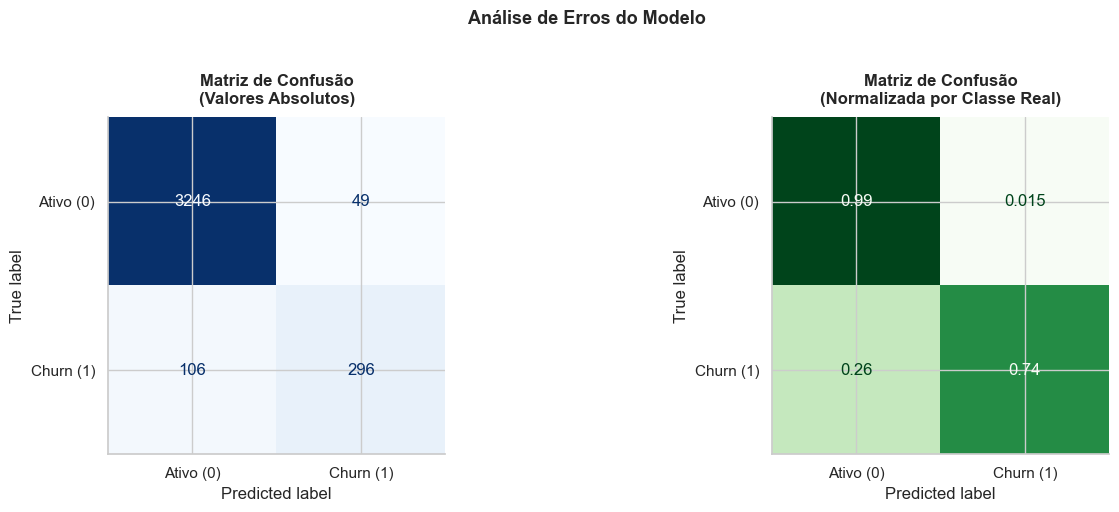


📋 Resumo da Matriz de Confusão:
   ✅ Verdadeiro Negativo (Ativo previsto como Ativo) : 3,246
   ✅ Verdadeiro Positivo (Churn previsto como Churn) :   296
   ❌ Falso Positivo (Ativo previsto como Churn)      :    49
   ❌ Falso Negativo (Churn previsto como Ativo)      :   106

   💡 106 clientes em churn não foram detectados pelo modelo.


In [13]:
# ── Matriz de Confusão ────────────────────────────────────────────────────
# Mostra exatamente onde o modelo acertou e onde errou
# Verdadeiro Positivo (VP): previu churn, era churn ✅
# Falso Positivo (FP): previu churn, mas era ativo ❌
# Falso Negativo (FN): previu ativo, mas era churn ❌
# Verdadeiro Negativo (VN): previu ativo, era ativo ✅

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão com valores absolutos
cm = confusion_matrix(y_teste, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Ativo (0)', 'Churn (1)'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusão\n(Valores Absolutos)', fontweight='bold', pad=10)

# Matriz de confusão normalizada
cm_norm = confusion_matrix(y_teste, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                    display_labels=['Ativo (0)', 'Churn (1)'])
disp_norm.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Matriz de Confusão\n(Normalizada por Classe Real)', fontweight='bold', pad=10)

plt.suptitle('Análise de Erros do Modelo', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Resumo dos erros
vn, fp, fn, vp = cm.ravel()
print(f"\n📋 Resumo da Matriz de Confusão:")
print(f"   ✅ Verdadeiro Negativo (Ativo previsto como Ativo) : {vn:>5,}")
print(f"   ✅ Verdadeiro Positivo (Churn previsto como Churn) : {vp:>5,}")
print(f"   ❌ Falso Positivo (Ativo previsto como Churn)      : {fp:>5,}")
print(f"   ❌ Falso Negativo (Churn previsto como Ativo)      : {fn:>5,}")
print(f"\n   💡 {fn} clientes em churn não foram detectados pelo modelo.")

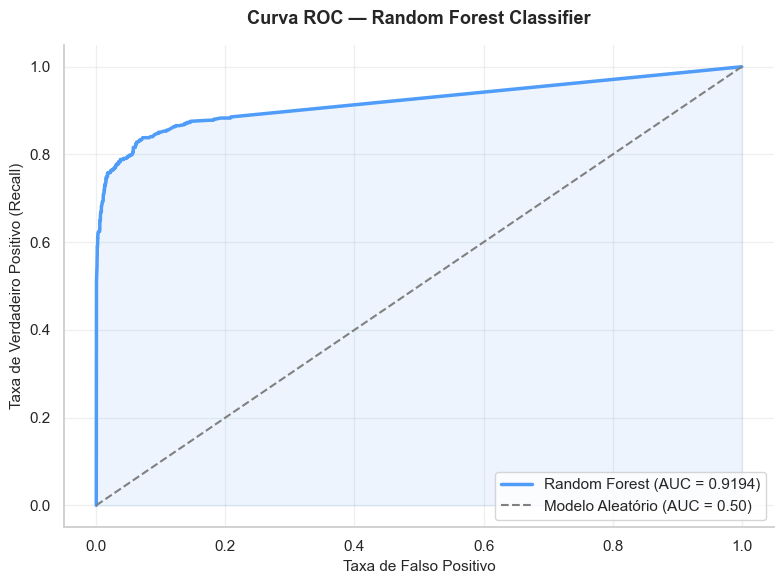


📊 ROC-AUC = 0.9194
   🏆 Classificação: EXCELENTE


In [14]:
# ── Curva ROC ─────────────────────────────────────────────────────────────
# Mostra o trade-off entre Taxa de Verdadeiro Positivo e Falso Positivo
# AUC próximo de 1.0 = modelo excelente | AUC = 0.5 = modelo aleatório

fpr, tpr, thresholds = roc_curve(y_teste, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#4f9cf9', linewidth=2.5,
         label=f'Random Forest (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         linewidth=1.5, label='Modelo Aleatório (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='#4f9cf9')
plt.xlabel('Taxa de Falso Positivo', fontsize=11)
plt.ylabel('Taxa de Verdadeiro Positivo (Recall)', fontsize=11)
plt.title('Curva ROC — Random Forest Classifier', fontsize=13, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 ROC-AUC = {auc:.4f}")
if auc >= 0.90:
    print("   🏆 Classificação: EXCELENTE")
elif auc >= 0.80:
    print("   ✅ Classificação: BOM")
elif auc >= 0.70:
    print("   ⚠️  Classificação: ACEITÁVEL")
else:
    print("   ❌ Classificação: FRACO — revisar modelo")

---
## 7️⃣ Feature Importance

O Random Forest nos diz quais features mais contribuíram para as previsões.
Isso é valioso para:
- Entender o comportamento do modelo
- Comunicar insights para o negócio
- Simplificar o modelo removendo features irrelevantes

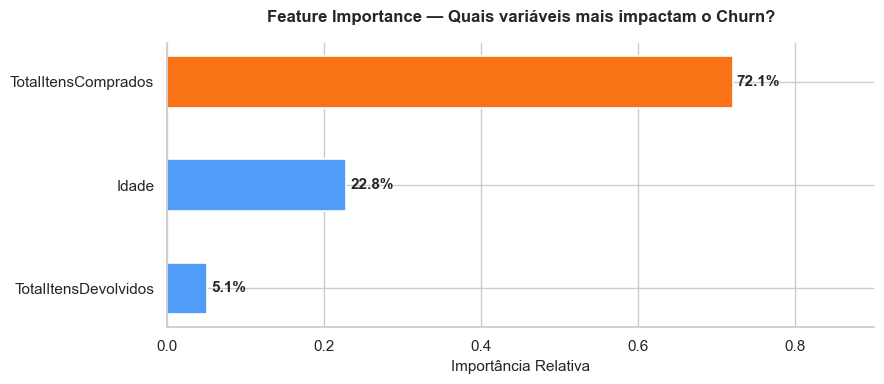


📊 Feature Importance detalhada:
   TotalItensComprados            ████████████████████████████████████ 72.08%
   Idade                          ███████████ 22.83%
   TotalItensDevolvidos           ██ 5.10%


In [15]:
# ── Importância das Features ──────────────────────────────────────────────
importancias = pd.DataFrame({
    'Feature': FEATURES,
    'Importancia': modelo_churn.feature_importances_
}).sort_values('Importancia', ascending=True)

# Gráfico de barras horizontais
cores_imp = ['#f97316' if i == importancias['Importancia'].idxmax() else '#4f9cf9'
             for i in importancias.index]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(importancias['Feature'], importancias['Importancia'],
               color=cores_imp, edgecolor='white', linewidth=1.2, height=0.5)

# Labels com percentual
for bar, val in zip(bars, importancias['Importancia']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Importância Relativa', fontsize=11)
ax.set_title('Feature Importance — Quais variáveis mais impactam o Churn?',
             fontweight='bold', pad=15, fontsize=12)
ax.set_xlim(0, importancias['Importancia'].max() * 1.25)
plt.tight_layout()
plt.show()

print("\n📊 Feature Importance detalhada:")
for _, row in importancias.sort_values('Importancia', ascending=False).iterrows():
    barra = '█' * int(row['Importancia'] * 50)
    print(f"   {row['Feature']:<30} {barra} {row['Importancia']*100:.2f}%")

---
## 8️⃣ Conclusões e Próximos Passos

### ✅ Resultados Obtidos

| Métrica | Valor |
|---|---|
| Acurácia Geral | 95.43% |
| Precisão (Churn) | 84% |
| Recall (Churn) | 73% |
| F1-Score (Churn) | 0.78 |

### 🔍 Diagnóstico
- O modelo tem **excelente performance para clientes ativos** (97% de precisão)
- Para churn, o **Recall de 73%** significa que ~27% dos clientes em risco não são detectados
- O dataset é **desbalanceado** (88% ativo vs 12% churn), o que pode ser melhorado

### 🚀 Próximos Passos

1. **Balancear classes** com `class_weight='balanced'` ou SMOTE
2. **Adicionar feature de Ticket Médio** para completar o RFM
3. **Ajustar threshold** de decisão para aumentar o Recall
4. **Testar XGBoost ou LightGBM** para comparação
5. **Exportar o modelo** com `joblib` para uso em produção
6. **Conectar ao Power BI** para dashboard de monitoramento de churn

---
*Jefferson da Silva Araújo · Analista de Dados · Contoso Retail DW*

In [16]:
# ── Resumo Final ──────────────────────────────────────────────────────────
print("=" * 55)
print(" RESUMO FINAL DO PROJETO")
print("=" * 55)
print(f" Dataset        : Contoso Retail DW")
print(f" Registros      : {len(df):>10,}")
print(f" Features       : {len(FEATURES):>10}")
print(f" Algoritmo      : Random Forest (100 árvores)")
print(f" Acurácia       : {acuracia*100:>9.2f}%")
print(f" ROC-AUC        : {auc:>10.4f}")
print("=" * 55)
print(" Autor: Jefferson da Silva Araújo")
print("=" * 55)

 RESUMO FINAL DO PROJETO
 Dataset        : Contoso Retail DW
 Registros      :     18,484
 Features       :          3
 Algoritmo      : Random Forest (100 árvores)
 Acurácia       :     95.81%
 ROC-AUC        :     0.9194
 Autor: Jefferson da Silva Araújo
